In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv("netflix_titles.csv")
df=df.dropna(subset=['type','release_year','rating','country','duration'])
type_count=df['type'].value_counts()

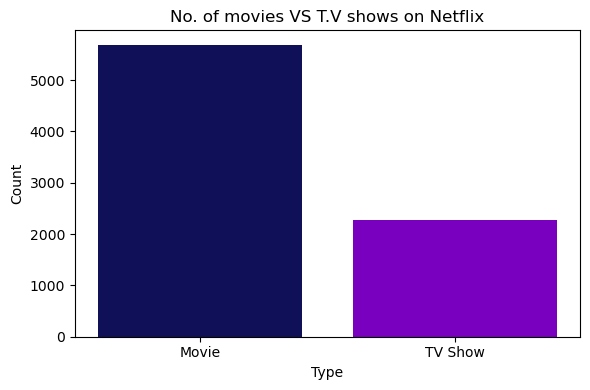

In [26]:
plt.figure(figsize=(6,4))
plt.bar(type_count.index,type_count.values,color=['#101058','#7900be'])
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('No. of movies VS T.V shows on Netflix')
plt.tight_layout()
plt.savefig('movies_vs_tv_shows.png')
plt.show()

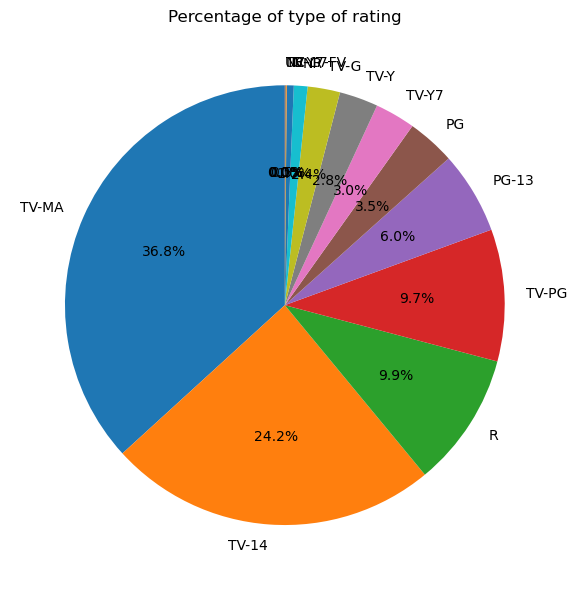

In [27]:
rating_count=df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_count.values,labels=rating_count.index,autopct='%1.1f%%',startangle=90)
plt.title('Percentage of type of rating')
plt.tight_layout()
plt.savefig('type_of_rating_pie.png')
plt.show()

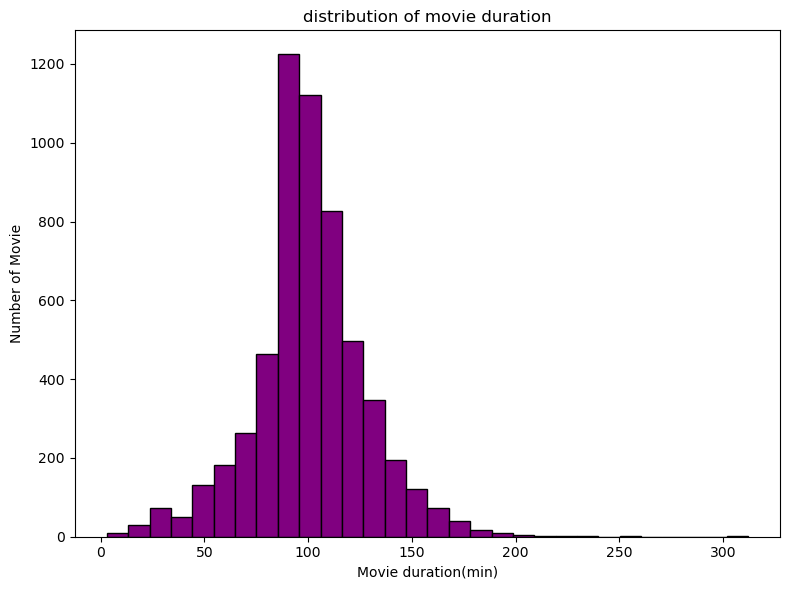

In [28]:
movie_df=df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] =movie_df['duration'].str.replace('min','').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30,color='purple',edgecolor='black')
plt.xlabel('Movie duration(min)')
plt.ylabel('Number of Movie')
plt.title('distribution of movie duration')
plt.tight_layout()
plt.savefig('movie_duration_histogram.png')
plt.show()

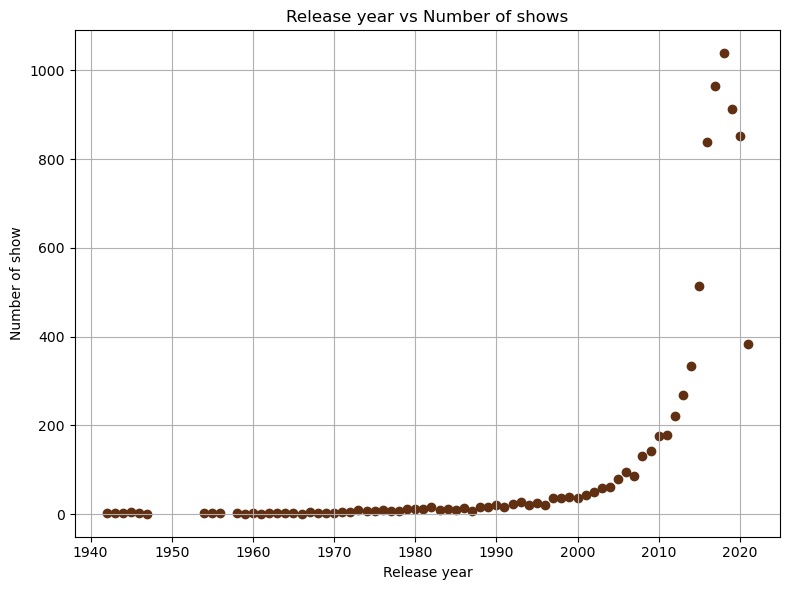

In [31]:
release_count=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,6))
plt.scatter(release_count.index,release_count.values,color='#612f12')
plt.title('Release year vs Number of shows')
plt.xlabel('Release year')
plt.ylabel('Number of show')
plt.grid()
plt.savefig('release_year_scatter.png')
plt.tight_layout()
plt.show()

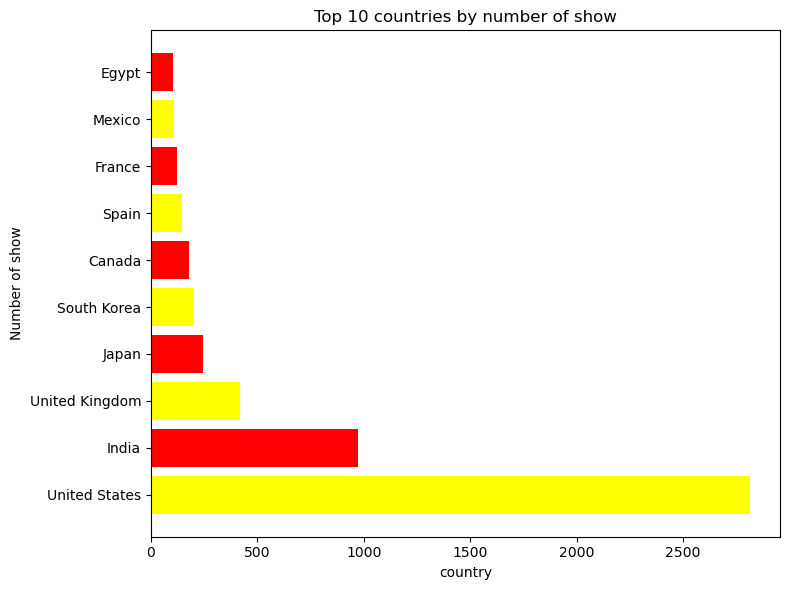

In [33]:
country_count=df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_count.index,country_count.values,color=['yellow','red'])
plt.xlabel('country')
plt.ylabel('Number of show')
plt.title('Top 10 countries by number of show')
plt.tight_layout()
plt.savefig('top_10_countries.png')
plt.show()

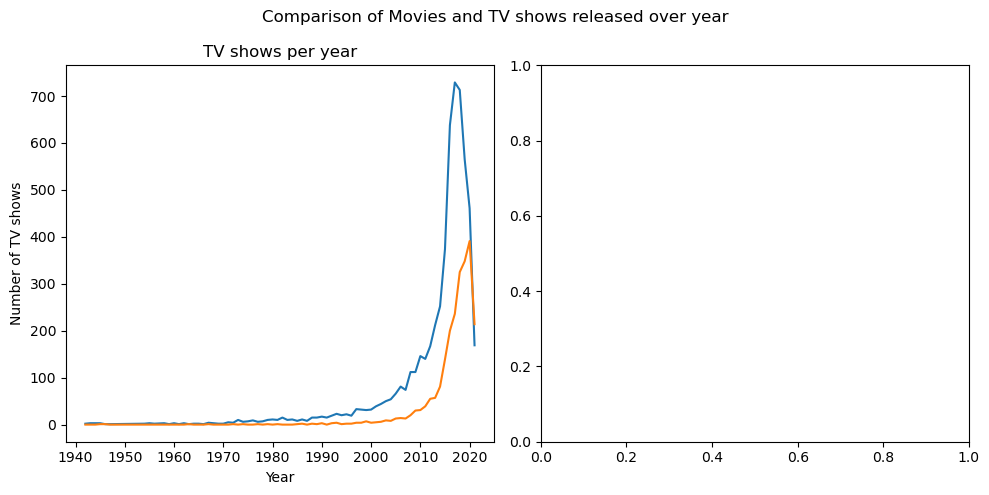

In [50]:
content_by_year=df.groupby(['release_year','type']).size().unstack().fillna(0)
fig, ax=plt.subplots(1,2,figsize=(10,5))
ax[0].plot(content_by_year.index,content_by_year['Movie'])
ax[0].set_title('Movies per year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of movie')

ax[0].plot(content_by_year.index,content_by_year['TV Show'])
ax[0].set_title('TV shows per year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of TV shows')

fig.suptitle('Comparison of Movies and TV shows released over year')
plt.tight_layout()
plt.savefig('movies_and_tv_shows_comparison.png')
plt.show()

